<a href="https://www.kaggle.com/code/nikita2901699/homework-nn?scriptVersionId=294460097" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [127]:
import torch  
from torchvision import datasets, transforms

In [128]:
data_dir = "/kaggle/input/fruit-recognition/train/train"

In [129]:
dataset = datasets.ImageFolder(data_dir)

In [130]:
len(dataset)

16854

In [131]:
img, label = dataset[3526]

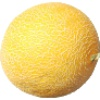

In [132]:
img 

In [133]:
dataset.classes

['Apple Braeburn',
 'Apple Granny Smith',
 'Apricot',
 'Avocado',
 'Banana',
 'Blueberry',
 'Cactus fruit',
 'Cantaloupe',
 'Cherry',
 'Clementine',
 'Corn',
 'Cucumber Ripe',
 'Grape Blue',
 'Kiwi',
 'Lemon',
 'Limes',
 'Mango',
 'Onion White',
 'Orange',
 'Papaya',
 'Passion Fruit',
 'Peach',
 'Pear',
 'Pepper Green',
 'Pepper Red',
 'Pineapple',
 'Plum',
 'Pomegranate',
 'Potato Red',
 'Raspberry',
 'Strawberry',
 'Tomato',
 'Watermelon']

In [134]:
data_train, data_test = torch.utils.data.random_split(dataset,[0.8, 0.2])

In [135]:
len(data_train)

13484

In [136]:
len(data_test)


3370

In [137]:
img, label = data_train[5000]


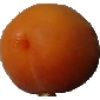

In [138]:
img

In [139]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    
])

In [140]:
train_transform(img).shape

torch.Size([3, 128, 128])

In [141]:
test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

In [142]:
test_transform(img).shape


torch.Size([3, 128, 128])

In [143]:
from torch.utils.data import Dataset,DataLoader

class TransformDataset(Dataset):
    def __init__(self, dataset, transformer):
        super().__init__()
        self.dataset = dataset
        self.transformer = transformer

    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        img, y = self.dataset[idx]

        new_img = self.transformer(img)
        
        return new_img, y

In [144]:
train_data = TransformDataset(data_train,train_transform)


In [145]:
test_data = TransformDataset(data_test,test_transform)


In [146]:
len(test_data)


3370

In [147]:
test_data[666]

(tensor([[[1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          ...,
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000]],
 
         [[0.9843, 0.9882, 0.9922,  ..., 1.0000, 1.0000, 1.0000],
          [0.9882, 0.9922, 0.9922,  ..., 1.0000, 1.0000, 1.0000],
          [0.9882, 0.9922, 0.9961,  ..., 1.0000, 1.0000, 1.0000],
          ...,
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000]],
 
         [[1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ...,

In [148]:
train_loader = DataLoader(train_data, batch_size=256)


In [149]:
test_loader = DataLoader(test_data, batch_size=256)


In [150]:
for img,idx in test_loader:
     print(img.shape)
     print(idx.shape) 

torch.Size([256, 3, 128, 128])
torch.Size([256])
torch.Size([256, 3, 128, 128])
torch.Size([256])
torch.Size([256, 3, 128, 128])
torch.Size([256])
torch.Size([256, 3, 128, 128])
torch.Size([256])
torch.Size([256, 3, 128, 128])
torch.Size([256])
torch.Size([256, 3, 128, 128])
torch.Size([256])
torch.Size([256, 3, 128, 128])
torch.Size([256])
torch.Size([256, 3, 128, 128])
torch.Size([256])
torch.Size([256, 3, 128, 128])
torch.Size([256])
torch.Size([256, 3, 128, 128])
torch.Size([256])
torch.Size([256, 3, 128, 128])
torch.Size([256])
torch.Size([256, 3, 128, 128])
torch.Size([256])
torch.Size([256, 3, 128, 128])
torch.Size([256])
torch.Size([42, 3, 128, 128])
torch.Size([42])


(128, 128, 3)


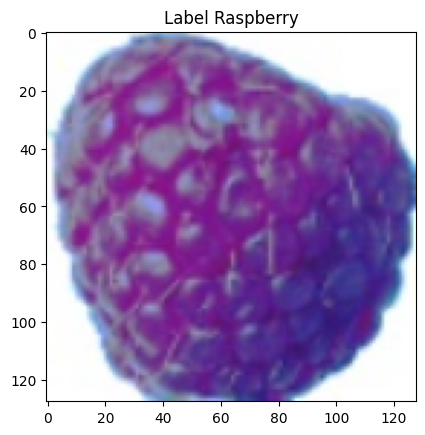

(128, 128, 3)


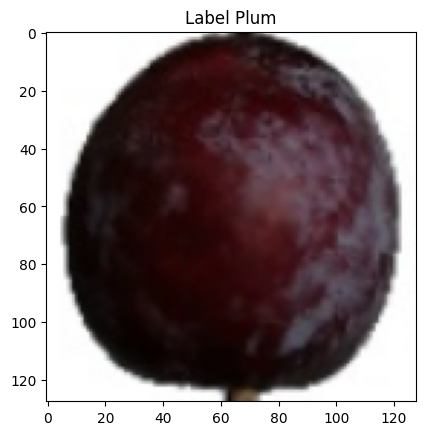

(128, 128, 3)


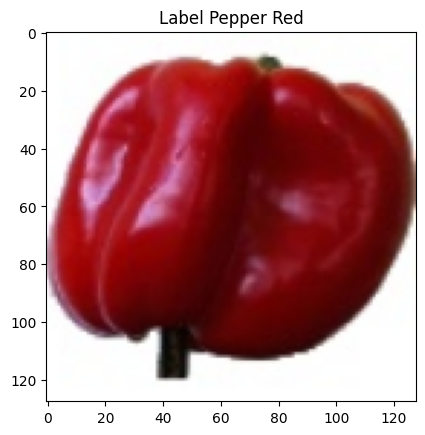

In [151]:
import matplotlib.pyplot as plt

for i in range(3):  # Show 3 images

    # Get the image data (tensor) and convert it back to a NumPy array for manipulation
    img, y = train_data[i]
    img = img.numpy()
    
    # Convert the color channels from (channels, height, width) to (height, width, channels) for pyplot
    img = img.transpose((1, 2, 0))
    print(img.shape)
    
    # Get the label name from the dataset class labels
    label = dataset.classes[y]

    # Plot the image with a title (including label name)
    plt.imshow(img)
    plt.title(f"Label {label}")
    plt.show()

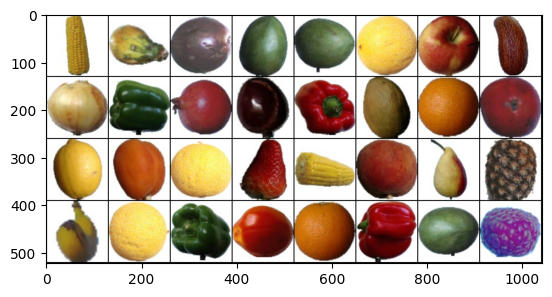

In [152]:
from torchvision.utils import make_grid

loader = torch.utils.data.DataLoader(train_data, shuffle=True, batch_size=32)

  
batch, labels = next(iter(loader))

grid = make_grid(batch).permute(1, 2, 0) # результатом є тензор

plt.imshow(grid)

In [153]:
3*64*64

12288

In [154]:
from torch import nn

# model = nn.Sequential(
#     nn.Flatten(),
#     nn.Linear(12288, 256),
#     nn.ReLU(),
#     nn.Linear(256, 128),
#     nn.ReLU(),
#     nn.Linear(128, 64),
#     nn.ReLU(),
#     nn.Linear(64, 33)
# )

model = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding='same'),# розмір буде 32,128,128
    nn.ReLU(),
    nn.MaxPool2d(2,2), #32, 64 , 64
    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding='same'),#64, 64, 64
    nn.ReLU(), # 64, 64, 64
    nn.MaxPool2d(2, 2), # 64, 32, 32
    nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding='same'), #128, 32, 32
    nn.ReLU(), #128, 32, 32
    nn.MaxPool2d(2, 2), # 128, 16, 16

    nn.Flatten(), # 32*25*25 - 20000
    nn.Linear(32768, 256),
    nn.ReLU(),
    nn.Linear(256, 33)
)

device = 'cuda'
model = model.to(device)



In [155]:
128*16*16

32768

In [156]:
for imgs, labels  in train_loader:
    break

In [157]:
imgs.shape

torch.Size([256, 3, 128, 128])

In [158]:
imgs = imgs.to(device)

In [159]:
res = model(imgs)
res.shape 

torch.Size([256, 33])

In [160]:
# функция ошибки для задачи многоклассовой классификации
loss_fn = nn.CrossEntropyLoss()

# оптимизатор Adam для обучения нейронной сети
optimizer = torch.optim.Adam(
    model.parameters(),   # параметры модели
    lr=0.001
)

# список для сохранения значений loss во время обучения
loss_list = []
loss_test_list = []

# цикл обучения по эпохам
for i in range(3):

    # перебор батчей из обучающего даталоадера
    for imgs, labels in train_loader:
        imgs = imgs.to(device)        # перенос изображений на GPU / CPU
        labels = labels.to(device)    # перенос меток на GPU / CPU

        result = model(imgs)          # прямой проход через модель
        loss = loss_fn(result, labels)  # вычисление функции потерь
        print(f"loss: {loss}")

        loss.backward()               # вычисление градиентов
        optimizer.step()              # обновление весов модели
        optimizer.zero_grad()         # очистка градиентов

        loss_list.append(loss.cpu().item())  # сохранение значения loss

    #test data
    for imgs, labels in train_loader:
        imgs = imgs.to(device)        # перенос изображений на GPU / CPU
        labels = labels.to(device)    # перенос меток на GPU / CPU

        result = model(imgs)          # прямой проход через модель
        loss = loss_fn(result, labels)  # вычисление функции потерь
        print(f"loss: {loss}")

        

        loss_test_list.append(loss.cpu().item())  # сохранение значения loss

loss: 3.4957430362701416
loss: 3.536285877227783
loss: 3.4493088722229004
loss: 3.3605520725250244
loss: 3.284146308898926
loss: 3.133054494857788
loss: 2.9050302505493164
loss: 2.7449491024017334
loss: 2.438019037246704
loss: 2.283512592315674
loss: 2.1036667823791504
loss: 1.9654762744903564
loss: 1.72355318069458
loss: 1.7444339990615845
loss: 1.5239698886871338
loss: 1.3585877418518066
loss: 1.1463901996612549
loss: 1.1094974279403687
loss: 1.075660228729248
loss: 1.060738444328308
loss: 0.9076806902885437
loss: 0.8409304618835449
loss: 0.8818725347518921
loss: 0.7025331854820251
loss: 0.6870582103729248
loss: 0.7583290338516235
loss: 0.585676908493042
loss: 0.6627191305160522
loss: 0.617522120475769
loss: 0.42865654826164246
loss: 0.4948364496231079
loss: 0.46941763162612915
loss: 0.41910094022750854
loss: 0.43679362535476685
loss: 0.4019964933395386
loss: 0.4575307369232178
loss: 0.39547330141067505
loss: 0.4116779565811157
loss: 0.39371615648269653
loss: 0.5170518159866333
loss:

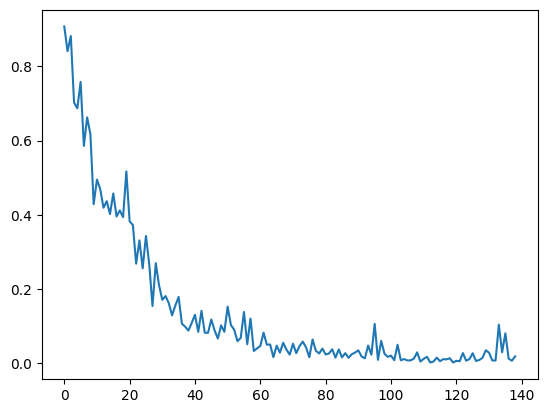

In [161]:
import matplotlib.pyplot as plt

new_list = loss_list[20 :]

plt.plot(new_list)


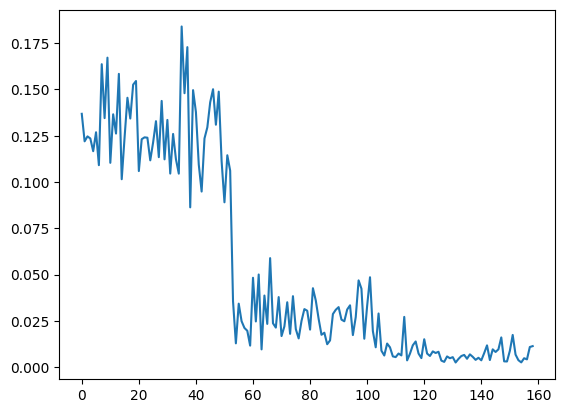

In [162]:
plt.plot(loss_test_list)

In [163]:
img, label = train_data[100]
img = img.unsqueeze(0)
img.shape

torch.Size([1, 3, 128, 128])

In [164]:
img = img.to(device)
prediction = model(img)
print(label)
print(nn.Softmax()(prediction))

15
tensor([[2.7021e-12, 1.8387e-06, 9.4683e-23, 1.3116e-13, 8.8365e-10, 8.2342e-23,
         2.8950e-07, 3.9303e-13, 1.5507e-19, 2.7475e-19, 5.6112e-11, 1.5721e-10,
         4.4043e-14, 4.6898e-08, 4.3433e-13, 1.0000e+00, 2.1843e-09, 1.9715e-08,
         4.5427e-16, 3.3192e-15, 6.4839e-08, 1.3881e-13, 6.3264e-08, 1.5583e-19,
         7.1813e-22, 2.8244e-08, 1.6563e-14, 7.4296e-10, 9.7802e-11, 8.0354e-10,
         1.1705e-15, 4.0008e-19, 3.1295e-07]], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)


In [165]:
result = model(imgs)

In [166]:
res1 = result.argmax(dim=1)

In [167]:
labels

tensor([ 3,  6, 22,  3, 27, 32, 12, 23, 17,  6,  4, 12, 32, 14, 25,  1, 11, 22,
        22, 14, 18, 15, 18,  8, 15, 28, 13, 24, 19, 31, 29, 16, 31, 11, 12, 23,
         4,  6, 22,  4,  9,  2,  8, 24,  4, 20,  1, 27, 10,  0, 15, 22, 32, 30,
        21, 18,  3,  5, 13, 23,  7,  7,  8,  0,  3, 29, 14, 32, 18, 31, 29, 10,
        25,  4, 29, 19,  2, 24,  5, 27, 11, 26,  6, 26,  7, 31,  9, 32,  9, 12,
        25,  0, 30, 21, 32, 23,  6,  1,  0, 19,  1, 31,  6, 12, 29,  5,  9,  1,
         7, 15,  6,  8, 18, 29, 25, 12, 32, 13, 28,  3,  3,  2,  4,  7,  9,  6,
        11, 25,  0,  2, 25,  6, 25, 11, 24, 26,  0, 31, 29,  9, 15, 23, 18, 23,
         6, 22, 12,  6,  8, 25, 20, 27, 11, 28, 18,  2, 21,  0, 30,  2, 14,  0,
         5,  2, 18, 16, 24, 22, 12,  1,  0, 18], device='cuda:0')

In [168]:
res2 = res1 == labels

In [169]:
res2.sum()

tensor(172, device='cuda:0')

In [170]:
count = 0



for imgs, labels in train_loader:
    imgs = imgs.to(device)
    labels = labels.to(device)
    res = model(imgs)
    res = res.argmax(dim=1)
    res2 = res == labels
    summa = res2.sum()
    count += summa.cpu().item()

print(count) 

13467


In [171]:
len(train_data) 

13484

In [173]:
13467/13484

0.9987392465143874